# CoMTE Implementation Comparison — FordA

`cfts/cf_comte/comte.py` used to contain only a gradient-based method that did **not** actually implement the CoMTE paper's algorithm (see below). It now also contains `comte_cf` — a faithful reimplementation of the real mechanism, validated in this notebook against the vendored official repo. The old gradient-based functions are kept, renamed with a `_gradient` suffix, for backward compatibility with existing example scripts — they are a different (and, relative to the paper, incorrect) family of methods, not alternate configurations of the same algorithm.

This notebook compares all of them on the **FordA** dataset (univariate, binary classification) using the pretrained SimpleCNN model:

| Variant | Source | Mechanism |
|---------|--------|-----------|
| `comte_cf` | `cfts/cf_comte/comte.py` | **This repo's canonical CoMTE implementation.** Dependency-light reimplementation of the real distractor + greedy channel/segment-swap mechanism — plain numpy/torch/sklearn, no pandas `MultiIndex`/sklearn-`Pipeline` adapter and no vendored repo required |
| `comte_original_bruteforce` | **Reference implementation**, [peaclab/CoMTE](https://github.com/peaclab/CoMTE) (`explainers.BruteForceSearch`) | Greedy channel-swap: repeatedly replaces the single most-improving channel from a real *distractor* example (a correctly-classified sample of the target class) |
| `comte_original_optimized` | **Reference implementation**, [peaclab/CoMTE](https://github.com/peaclab/CoMTE) (`explainers.OptimizedSearch`) | Discrete optimization (`mlrose` random-hill-climb) over the subset of channels to swap from a distractor, falling back to `BruteForceSearch` if it finds nothing |
| `comte_cf_gradient` | `cfts/cf_comte/comte.py` (legacy, was `comte_cf`) | Gradient-based adversarial perturbation: Adam optimizes the *entire* continuous input against a cross-entropy + L2 + L1 objective (two-phase: prediction-only, then + proximity/sparsity) |
| `comte_ts_cf_gradient` | `cfts/cf_comte/comte.py` (legacy, was `comte_ts_cf`) | Same gradient scheme, with added temporal-smoothness and trend-preservation regularizers |

**Why `comte_cf_gradient` / `comte_ts_cf_gradient` are not the paper's algorithm:** the paper (Ates et al., 2021, ICAPAI) and its official code build counterfactuals by substituting whole **channels** of a multivariate sample with the corresponding channel from a real, correctly-classified example of the target class ("distractor"), searching over *which channels* to swap via greedy search or discrete optimization — never touching a gradient. These legacy functions instead run continuous, gradient-based Adam optimization directly on the raw waveform, which is architecturally the same family as this repo's `cf_wachter`/`cf_cem`-style methods. Their original docstrings' description ("optimizing each channel independently... smoothness and sparsity constraints") was a loose paraphrase of the paper's motivation, not a description of what the code actually does — which is why they were renamed off the primary `comte_cf` name rather than left in place.

So this notebook does three things at once:
1. Runs the **real** CoMTE algorithm (via the vendored official repo) on FordA, which requires one nontrivial adaptation (see below);
2. Runs `comte_cf` — this repo's own from-scratch reimplementation of that same real mechanism, built directly against this project's plain PyTorch model interface rather than the official repo's sklearn-`Pipeline`/pandas-`MultiIndex` API, so it can be checked against the vendored original on identical data and used elsewhere in this repo without the extra `mlrose`/`scikit-optimize`/`tables` dependencies; and
3. Shows, quantitatively, how differently the legacy gradient-based methods behave from the real distractor-swap mechanism — not because one is a buggy version of the other, but because they are different algorithms that happened to share a name until this cleanup.

**Adapting CoMTE to univariate data.** The official algorithm's swap unit is a whole *channel* (a full-length time series for one sensor/variable), which only makes sense for genuinely multivariate data (its own examples use NATOPS — 24 channels — and an HPC telemetry dataset). FordA has a single channel of 500 points, so swapping "the channel" would just mean swapping the entire series with the distractor's — not an interesting explanation. To give the official algorithm the same kind of combinatorial search space it was designed for, we chop each 500-point series into **10 contiguous segments of 50 points** and treat each segment as a pseudo-channel/"column" in the sense CoMTE's `explainers.py` expects. Swapping "segment 7" then means replacing time steps 350–399 with the distractor's values at those same steps — a faithful, if repo-specific, generalization of the channel-swap idea to a single channel. This is the only structural change made to the official code; the search/optimization logic (`BaseExplanation`, `BruteForceSearch`, `OptimizedSearch` in `explainers.py`) runs unmodified.

**Vendoring.** The official repo is cloned as-is into a **gitignored** directory (matched by the `**/external/` rule in `.gitignore`), the same pattern used for the MASCOTS baseline in this repo:

```bash
mkdir -p cfts/cf_comte/external
git clone https://github.com/peaclab/CoMTE.git cfts/cf_comte/external/comte_github
```

No source changes were needed inside the clone — it imports and runs unmodified against this project's modern `numpy`/`scipy`/`scikit-learn`/`pandas` versions. Two extra (standard, PyPI) dependencies were installed into the project venv purely because `explainers.py` imports them at module load time even though we never call the code paths that use them for our purposes: `scikit-optimize` (`skopt`, used only by `local_lipschitz_estimate`, which this notebook doesn't call) and `tables` (only needed if you go through the repo's own HDF-based `data_loading.py`, which we bypass). `mlrose` (the actual optimizer used by `OptimizedSearch`) was installed with `--no-deps` because its PyPI metadata still requires the deprecated `sklearn` shim package, which refuses to build against modern pip — `mlrose` itself only needs `numpy`/`scipy`, both already satisfied by this project's environment.

If `cfts/cf_comte/external/comte_github` isn't present, the cells below skip the two `comte_original_*` baselines gracefully and the rest of the notebook still runs with the three `comte.py` variants (`comte_cf`, `comte_cf_gradient`, `comte_ts_cf_gradient`).

**References**
- Ates, E., Aksar, B., Leung, V. J., & Coskun, A. K. (2021). *Counterfactual Explanations for Multivariate Time Series.* ICAPAI 2021. [PDF](https://www.bu.edu/peaclab/files/2021/05/CoMTE___ICAPAI.pdf) / [arXiv:2008.10781](https://arxiv.org/pdf/2008.10781.pdf)
- Official code: https://github.com/peaclab/CoMTE

In [1]:
from __future__ import annotations

import random
import sys
import time
import warnings
from pathlib import Path
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import f1_score

warnings.filterwarnings("ignore")

# Locate repo root
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "cfts").exists():
        sys.path.insert(0, str(candidate))
        sys.path.insert(0, str(candidate / "examples"))
        REPO_ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate repository root containing cfts/")

from base.data import get_UCR_UEA_dataloader
from base.model import SimpleCNN
from cfts.cf_comte.comte import comte_cf, comte_cf_gradient, comte_ts_cf_gradient
from cfts.metrics import (
    autocorrelation_preservation,
    dtw_distance,
    evaluate_keane_metrics,
    feature_range_validity,
    l2_distance,
    normalized_distance,
    percentage_changed_points,
    prediction_change,
)

plt.style.use("seaborn-v0_8-darkgrid")
np.random.seed(42)
random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Repo root: {REPO_ROOT}")

Using device: cpu
Repo root: /workspaces/counterfactual-explanations-for-time-series


In [2]:
# Load FordA dataset and pretrained model
_, dataset_train = get_UCR_UEA_dataloader(dataset_name="FordA", split="train")
_, dataset_test = get_UCR_UEA_dataloader(dataset_name="FordA", split="test")

output_classes = dataset_train.y_shape[1]
input_length = dataset_train.X_shape[2]

model = SimpleCNN(output_channels=output_classes, input_length=input_length).to(device)

model_path = REPO_ROOT / "models" / f"simple_cnn_forda_{output_classes}.pth"
if not model_path.exists():
    raise FileNotFoundError(
        f"Pretrained model not found at {model_path}.\n"
        "Run examples/example_univariate.py first to train and save the model."
    )

state = torch.load(model_path, map_location=device)
model.load_state_dict(state)
model.eval()
print(f"Loaded model from {model_path}")


def predict_scores(model, sample, device):
    """Return the model's output (post-softmax, per SimpleCNN's own final layer) as (n_classes,)."""
    ts = torch.tensor(np.asarray(sample, dtype=np.float32), device=device)
    if ts.ndim == 1:
        ts = ts.reshape(1, 1, -1)
    elif ts.ndim == 2:
        if ts.shape[0] > ts.shape[1]:
            ts = ts.T
        ts = ts.unsqueeze(0)
    with torch.no_grad():
        return model(ts).detach().cpu().numpy().reshape(-1)


def to_class_index(label):
    arr = np.asarray(label)
    return int(np.argmax(arr)) if arr.ndim > 0 else int(arr)


def to_channel_first(sample):
    arr = np.asarray(sample, dtype=np.float32)
    if arr.ndim == 1:
        return arr.reshape(1, -1)
    if arr.ndim == 2:
        return arr if arr.shape[0] <= arr.shape[1] else arr.T
    if arr.ndim == 3:
        return arr[0]
    raise ValueError(f"Unsupported shape: {arr.shape}")


y_true, y_pred = [], []
for sample, label in dataset_test:
    scores = predict_scores(model, sample, device)
    y_true.append(to_class_index(label))
    y_pred.append(int(np.argmax(scores)))

test_f1 = f1_score(y_true, y_pred, average="macro")
print(f"Train size: {len(dataset_train)} | Test size: {len(dataset_test)}")
print(f"Input length: {input_length} | Classes: {output_classes}")
print(f"Test macro F1: {test_f1:.4f}")

Loaded model from /workspaces/counterfactual-explanations-for-time-series/models/simple_cnn_forda_2.pth


Train size: 3601 | Test size: 1320
Input length: 500 | Classes: 2
Test macro F1: 0.9220


## Official CoMTE baseline (peaclab/CoMTE)

Clone the authors' own code as described above (skipped gracefully if not present):

```bash
mkdir -p cfts/cf_comte/external
git clone https://github.com/peaclab/CoMTE.git cfts/cf_comte/external/comte_github
```

The cells below build a thin adapter so the official `explainers.py` (which expects a fitted `sklearn.Pipeline`-like object and a `pandas` `MultiIndex` `(node_id, position)` DataFrame — the format used by the authors' own NATOPS/HPC examples) can drive our PyTorch `SimpleCNN` directly on FordA's raw waveform, segmented into 10 pseudo-channels as explained above.

In [3]:
EXTERNAL_COMTE_DIR = REPO_ROOT / "cfts" / "cf_comte" / "external" / "comte_github"

HAVE_ORIGINAL_COMTE = EXTERNAL_COMTE_DIR.exists()

if HAVE_ORIGINAL_COMTE:
    sys.path.insert(0, str(EXTERNAL_COMTE_DIR))
    try:
        import explainers as comte_explainers  # official peaclab/CoMTE
        print(f"Loaded original CoMTE implementation from {EXTERNAL_COMTE_DIR}")
    except ImportError as exc:
        HAVE_ORIGINAL_COMTE = False
        print(f"Found {EXTERNAL_COMTE_DIR} but failed to import explainers.py ({exc}).")
        print("Install: mlrose (--no-deps), scikit-optimize, tables.")
else:
    print(
        f"{EXTERNAL_COMTE_DIR} not found — skipping the comte_original_* baselines.\n"
        "See the markdown cell above for the clone steps."
    )

Loaded original CoMTE implementation from /workspaces/counterfactual-explanations-for-time-series/cfts/cf_comte/external/comte_github


In [4]:
# --- Segment adapter: turn a univariate (L,) waveform into the (node_id, position) x segment
#     MultiIndex DataFrame the official explainers.py expects, and back. ---

N_SEGMENTS = 10
assert input_length % N_SEGMENTS == 0, "input_length must divide evenly for this simple adapter"
SEGMENT_LEN = input_length // N_SEGMENTS
SEGMENT_NAMES = [f"seg_{i}" for i in range(N_SEGMENTS)]


def to_segment_df(sample_1d: np.ndarray, node_id: str) -> pd.DataFrame:
    """(L,) -> DataFrame indexed by (node_id, position within segment), columns = pseudo-channels."""
    segments = sample_1d.reshape(N_SEGMENTS, SEGMENT_LEN).T  # (segment_len, n_segments)
    idx = pd.MultiIndex.from_product([[node_id], range(SEGMENT_LEN)], names=["node_id", "pos"])
    return pd.DataFrame(segments, index=idx, columns=SEGMENT_NAMES)


def from_segment_df(df: pd.DataFrame, node_id: str) -> np.ndarray:
    """Inverse of to_segment_df for a single node_id block -> (L,) waveform."""
    block = df.loc[[node_id], :].sort_index(level="pos")
    return np.concatenate([block[seg].values for seg in SEGMENT_NAMES]).astype(np.float32)


class CNNClfAdapter:
    """Just enough of a fitted sklearn Pipeline's surface for explainers.BaseExplanation & friends:
    `.steps[0][1].column_names`, `.classes_`, `.predict_proba(df)`, `.predict(df)` — grouped by node_id.
    """

    def __init__(self, model, device):
        self.model = model
        self.device = device
        self.classes_ = np.array([0, 1])
        self.steps = [("check", SimpleNamespace(column_names=SEGMENT_NAMES))]

    def predict_proba(self, df: pd.DataFrame) -> np.ndarray:
        node_ids = list(dict.fromkeys(df.index.get_level_values("node_id")))
        batch = np.stack([from_segment_df(df, nid) for nid in node_ids], axis=0)
        x = torch.tensor(batch, dtype=torch.float32, device=self.device).unsqueeze(1)
        with torch.no_grad():
            return self.model(x).cpu().numpy()

    def predict(self, df: pd.DataFrame) -> np.ndarray:
        return np.argmax(self.predict_proba(df), axis=1)


clf_adapter = CNNClfAdapter(model, device)

# Background set used for distractor search (KDTree over correctly-classified training samples)
BG_SIZE = min(200, len(dataset_train))
bg_frames, bg_label_rows = [], []
for i in range(BG_SIZE):
    x, y = dataset_train[i]
    node_id = f"train_{i}"
    bg_frames.append(to_segment_df(np.asarray(x, dtype=np.float32).reshape(-1), node_id))
    bg_label_rows.append({"node_id": node_id, "label": int(np.argmax(y))})

comte_timeseries = pd.concat(bg_frames, axis=0)
comte_labels = pd.DataFrame(bg_label_rows)
comte_labels.index = pd.MultiIndex.from_arrays(
    [comte_labels["node_id"], [0] * len(comte_labels)], names=["node_id", "row"]
)

print(f"Background timeseries shape: {comte_timeseries.shape} ({BG_SIZE} samples x {N_SEGMENTS} segments)")
print(f"Background label distribution: {comte_labels['label'].value_counts().to_dict()}")

# Same background pool, as (x, y) pairs — the format `comte_cf` (and most other CF
# methods in this repo) expects for its `dataset` argument.
background_dataset = [
    (np.asarray(dataset_train[i][0], dtype=np.float32), np.asarray(dataset_train[i][1], dtype=np.float32))
    for i in range(BG_SIZE)
]
print(f"Background dataset (for comte_cf): {len(background_dataset)} (x, y) pairs")

# num_distractors=1 (vs the library default of 2) purely to keep this demo notebook's total
# runtime manageable — OptimizedSearch's mlrose random-hill-climb (5 restarts, 1000 attempts/iters,
# hardcoded inside explainers.opt_Discrete) is run once per distractor and costs ~15-20s each on CPU.
# Used for comte_cf too, so all three distractor-swap-based methods search the same way.
NUM_DISTRACTORS = 1

if HAVE_ORIGINAL_COMTE:
    comte_original_bruteforce = comte_explainers.BruteForceSearch(
        clf_adapter, comte_timeseries, comte_labels, silent=True, num_distractors=NUM_DISTRACTORS, threads=1
    )
    comte_original_optimized = comte_explainers.OptimizedSearch(
        clf_adapter, comte_timeseries, comte_labels, silent=True, num_distractors=NUM_DISTRACTORS, threads=1
    )
    print("Instantiated BruteForceSearch and OptimizedSearch from the official repo.")

Background timeseries shape: (10000, 10) (200 samples x 10 segments)
Background label distribution: {0: 106, 1: 94}
Background dataset (for comte_cf): 200 (x, y) pairs
Instantiated BruteForceSearch and OptimizedSearch from the official repo.


### Quick single-sample walkthrough (official `OptimizedSearch`)

True label: 0 | Predicted: 0 (scores=[9.9999988e-01 1.6135729e-07]) | Target: 1


Swapped segments: ['seg_4', 'seg_5', 'seg_6', 'seg_9'] (took 11.9s)
CF predicted: 1 (scores=[0.16706547 0.83293456])


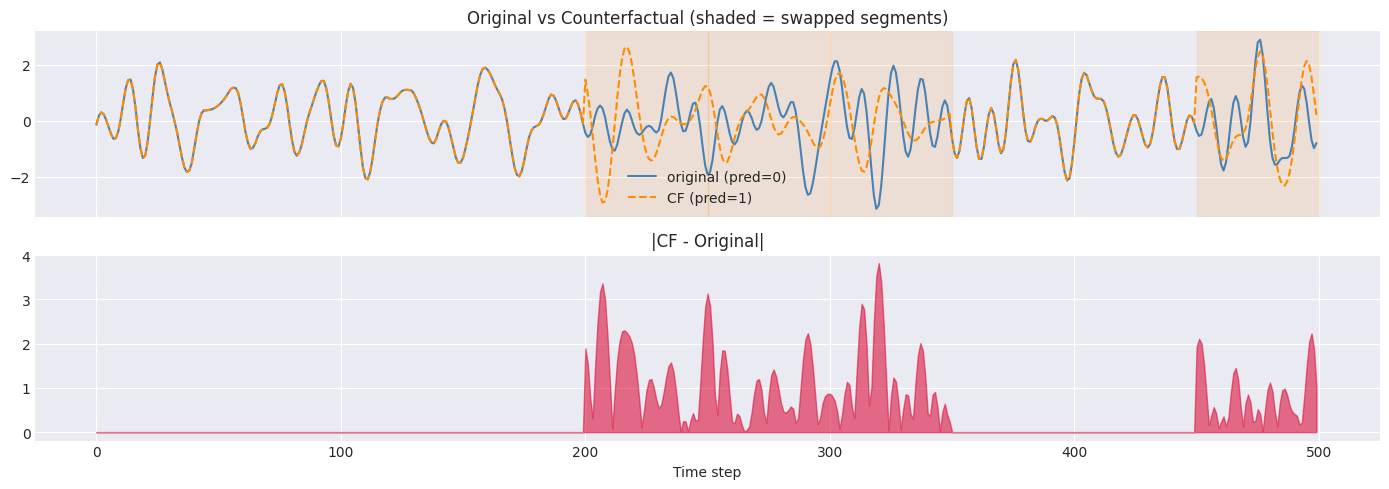

In [5]:
if HAVE_ORIGINAL_COMTE:
    sample_raw, label_raw = dataset_test[0]
    sample_raw = np.asarray(sample_raw, dtype=np.float32).reshape(-1)
    scores_orig = predict_scores(model, sample_raw, device)
    pred_orig = int(np.argmax(scores_orig))
    true_label = to_class_index(label_raw)
    target_class = int(np.argmin(scores_orig))  # binary: "other" class

    print(f"True label: {true_label} | Predicted: {pred_orig} (scores={scores_orig}) | Target: {target_class}")

    x_test_df = to_segment_df(sample_raw, "query")
    t0 = time.time()
    explanation, dist = comte_original_optimized.explain(x_test_df, to_maximize=target_class, return_dist=True)
    elapsed = time.time() - t0

    modified = x_test_df.copy()
    for c in explanation:
        modified[c] = dist[c].values
    cf_scores = clf_adapter.predict_proba(modified)[0]
    cf_1d = from_segment_df(modified, "query")

    print(f"Swapped segments: {sorted(explanation)} (took {elapsed:.1f}s)")
    print(f"CF predicted: {int(np.argmax(cf_scores))} (scores={cf_scores})")

    fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
    axes[0].plot(sample_raw, color="steelblue", linewidth=1.5, label=f"original (pred={pred_orig})")
    axes[0].plot(cf_1d, color="darkorange", linewidth=1.5, linestyle="--", label=f"CF (pred={int(np.argmax(cf_scores))})")
    for seg_name in explanation:
        seg_idx = SEGMENT_NAMES.index(seg_name)
        axes[0].axvspan(seg_idx * SEGMENT_LEN, (seg_idx + 1) * SEGMENT_LEN, color="darkorange", alpha=0.12)
    axes[0].set_title("Original vs Counterfactual (shaded = swapped segments)")
    axes[0].legend()
    axes[1].fill_between(np.arange(len(sample_raw)), 0, np.abs(cf_1d - sample_raw), color="crimson", alpha=0.6)
    axes[1].set_title("|CF - Original|")
    axes[1].set_xlabel("Time step")
    plt.tight_layout()
    plt.show()
else:
    print("Skipping — official CoMTE not available.")

In [6]:
def model_wrapper(ts: np.ndarray) -> np.ndarray:
    """(N, L) or (C, L) -> scores array, for metrics helpers."""
    return predict_scores(model, np.asarray(ts, dtype=np.float32), device)


def infer_target_class(scores: np.ndarray) -> int:
    order = np.argsort(scores)[::-1]
    return int(order[1])


def select_correct_indices(dataset, max_count: int) -> list[int]:
    selected = []
    for idx in range(len(dataset)):
        sample, label = dataset[idx]
        scores = predict_scores(model, np.asarray(sample, dtype=np.float32), device)
        if int(np.argmax(scores)) == to_class_index(label):
            selected.append(idx)
        if len(selected) >= max_count:
            break
    return selected


reference_data = np.stack(
    [np.asarray(dataset_train[i][0], dtype=np.float32) for i in range(min(256, len(dataset_train)))],
    axis=0,
)


def compute_metrics(sample_cf, cf_cf, target_class):
    """Quality metrics for (sample, counterfactual), both as (C, L) arrays."""
    keane = evaluate_keane_metrics(
        original_ts_list=sample_cf,
        counterfactual_ts_list=cf_cf,
        model=model_wrapper,
        target_classes=int(target_class),
    )
    return {
        "l2_norm": float(l2_distance(sample_cf, cf_cf)),
        "dtw_proximity": float(dtw_distance(sample_cf, cf_cf)),
        "normalized_distance": float(normalized_distance(sample_cf.reshape(-1), cf_cf.reshape(-1))),
        "sparsity": float(1.0 - percentage_changed_points(sample_cf, cf_cf)),
        "range_validity": float(feature_range_validity(cf_cf, reference_data)),
        "autocorr": float(autocorrelation_preservation(sample_cf, cf_cf)),
        "keane_validity": float(keane["validity"]),
        "keane_proximity": float(keane["proximity"]),
        "keane_compactness": float(keane["compactness"]),
        "validity": float(prediction_change(sample_cf, cf_cf, model_wrapper, target_class=target_class)),
    }

In [7]:
N_SAMPLES = 15  # kept modest: comte_original_optimized costs ~15-20s/sample on CPU (mlrose hill-climb)

selected_indices = select_correct_indices(dataset_test, max_count=N_SAMPLES)
print(f"Evaluating on {len(selected_indices)} correctly classified test samples.")

Evaluating on 15 correctly classified test samples.


In [8]:
def run_comte_original(sample_raw, target_class, explainer):
    x_test_df = to_segment_df(sample_raw, "query")
    explanation, dist = explainer.explain(x_test_df, to_maximize=target_class, return_dist=True)
    if not explanation:
        return None, None
    modified = x_test_df.copy()
    for c in explanation:
        modified[c] = dist[c].values
    cf_1d = from_segment_df(modified, "query")
    probs = clf_adapter.predict_proba(modified)[0]
    return cf_1d, probs


METHODS = {
    "comte_cf": lambda sample, target: comte_cf(
        sample, model, target_class=target, dataset=background_dataset,
        n_segments=N_SEGMENTS, num_distractors=NUM_DISTRACTORS,
    ),
    "comte_cf_gradient": lambda sample, target: comte_cf_gradient(sample, model, target_class=target, dataset=dataset_test),
    "comte_ts_cf_gradient": lambda sample, target: comte_ts_cf_gradient(sample, model, target_class=target, dataset=dataset_test),
}
if HAVE_ORIGINAL_COMTE:
    METHODS["comte_original_bruteforce"] = lambda sample, target: run_comte_original(
        sample, target, comte_original_bruteforce
    )
    METHODS["comte_original_optimized"] = lambda sample, target: run_comte_original(
        sample, target, comte_original_optimized
    )

records = []
all_cfs = {}  # {sample_idx: {method: cf_array}}

for idx in selected_indices:
    sample, label = dataset_test[idx]
    sample = np.asarray(sample, dtype=np.float32).reshape(-1)
    scores_orig = predict_scores(model, sample, device)
    pred_orig = int(np.argmax(scores_orig))
    true_label = to_class_index(label)
    target_class = infer_target_class(scores_orig)

    all_cfs[idx] = {"sample": sample, "true_label": true_label, "target_class": target_class}

    for method_name, runner in METHODS.items():
        base = {
            "sample_idx": idx, "method": method_name,
            "true_label": true_label, "pred_orig": pred_orig,
            "target_class": target_class,
            "pred_cf": None, "success": False,
            "l2_norm": np.nan, "dtw_proximity": np.nan,
            "normalized_distance": np.nan, "sparsity": np.nan,
            "range_validity": np.nan, "autocorr": np.nan,
            "keane_validity": np.nan, "keane_proximity": np.nan,
            "keane_compactness": np.nan, "validity": 0.0,
            "error": None,
        }

        t0 = time.time()
        try:
            cf, pred_cf_scores = runner(sample, target_class)
        except Exception as exc:
            records.append({**base, "error": f"{type(exc).__name__}: {exc}"})
            continue
        elapsed = time.time() - t0

        if cf is None or pred_cf_scores is None:
            records.append({**base, "error": "Returned None", "runtime_s": elapsed})
            continue

        cf = np.asarray(cf, dtype=np.float32)
        pred_cf_arr = np.asarray(pred_cf_scores).reshape(-1)
        pred_cf = int(np.argmax(pred_cf_arr))
        success = (pred_cf == target_class)

        sample_cf = to_channel_first(sample)
        cf_cf = to_channel_first(cf)

        metrics = compute_metrics(sample_cf, cf_cf, target_class)
        records.append({
            **base,
            "pred_cf": pred_cf,
            "success": success,
            "runtime_s": elapsed,
            **metrics,
        })
        all_cfs[idx][method_name] = cf

results_df = pd.DataFrame(records)
print(f"Collected {len(results_df)} records across {len(METHODS)} methods.")

Collected 75 records across 5 methods.


In [9]:
# Aggregate summary — only successful CFs contribute to distance metrics
successful_df = results_df[results_df["success"] == True].copy()

summary_df = (
    results_df.groupby("method")
    .agg(
        n_total=("sample_idx", "count"),
        n_successful=("success", "sum"),
        success_rate=("success", "mean"),
        validity_mean=("validity", "mean"),
        runtime_mean_s=("runtime_s", "mean"),
    )
    .reset_index()
    .merge(
        successful_df.groupby("method")
        .agg(
            l2_norm_mean=("l2_norm", "mean"),
            dtw_proximity_mean=("dtw_proximity", "mean"),
            normalized_distance_mean=("normalized_distance", "mean"),
            sparsity_mean=("sparsity", "mean"),
            range_validity_mean=("range_validity", "mean"),
            autocorr_mean=("autocorr", "mean"),
            keane_proximity_mean=("keane_proximity", "mean"),
            keane_compactness_mean=("keane_compactness", "mean"),
        )
        .reset_index(),
        on="method",
        how="left",
    )
)
summary_df["success_rate"] = (100.0 * summary_df["success_rate"]).round(1)
summary_df["n_successful"] = summary_df["n_successful"].fillna(0).astype(int)

display_cols = [
    "method", "n_successful", "success_rate", "validity_mean", "runtime_mean_s",
    "l2_norm_mean", "dtw_proximity_mean", "sparsity_mean",
    "range_validity_mean", "autocorr_mean",
    "keane_proximity_mean", "keane_compactness_mean",
]
summary_df[display_cols].sort_values("method").round(4)

,method,n_successful,success_rate,validity_mean,runtime_mean_s,l2_norm_mean,dtw_proximity_mean,sparsity_mean,range_validity_mean,autocorr_mean,keane_proximity_mean,keane_compactness_mean
0,comte_cf,15,100.0,1.0,0.0542,15.8701,7.0170,0.6533,0.9601,0.9923,15.8701,0.6559
1,comte_cf_gradient,15,100.0,1.0,5.5355,10.5157,8.8747,0.0000,0.9259,0.9929,10.5157,0.0049
2,comte_original_bruteforce,15,100.0,1.0,0.0557,15.8701,7.0170,0.6533,0.9601,0.9923,15.8701,0.6559
3,comte_original_optimized,15,100.0,1.0,67.1061,15.8969,6.9838,0.6133,0.9519,0.9897,15.8969,0.6168
4,comte_ts_cf_gradient,15,100.0,1.0,126.0326,9.0513,7.5098,0.0000,0.9352,0.9934,9.0513,0.0081


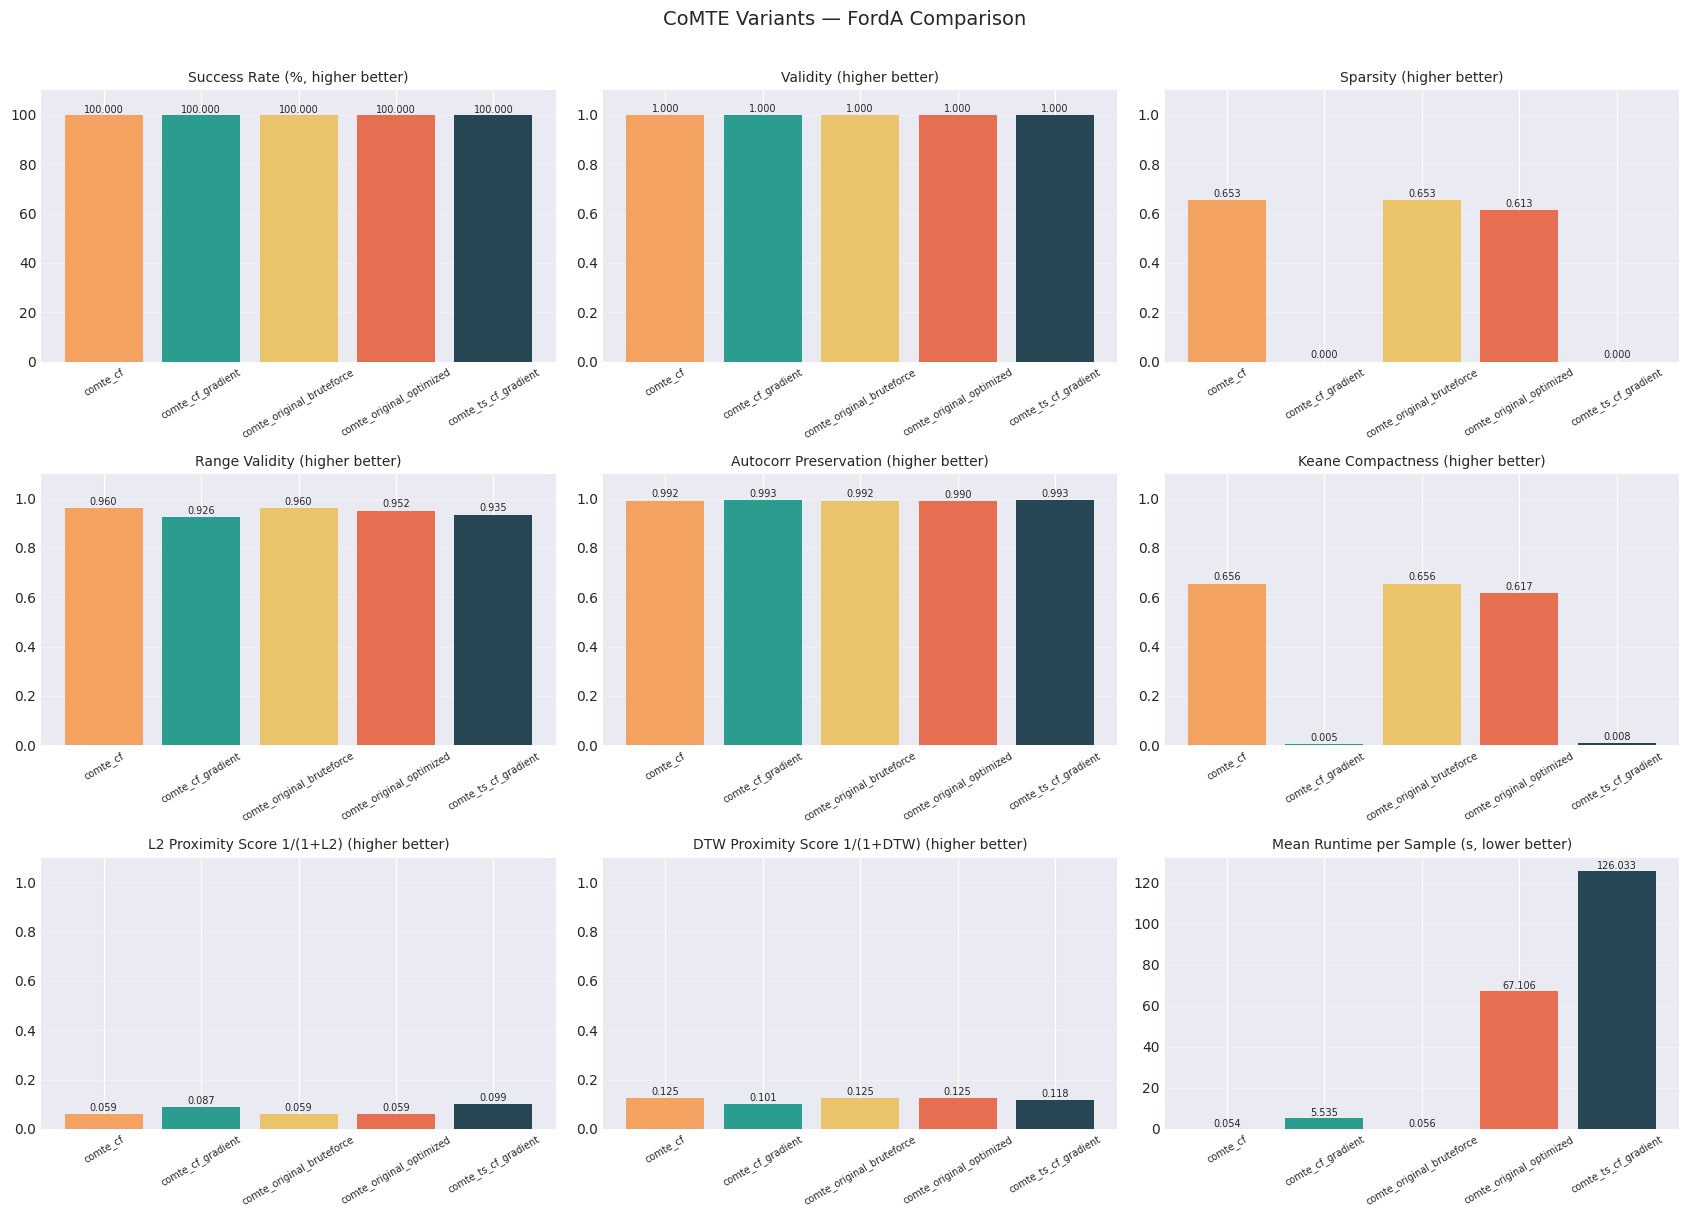

In [10]:
# Bar chart comparison across all methods
# (colors follow the underlying algorithm, not the label: comte_cf keeps the
# color comte_reimp used before this cleanup renamed it; comte_cf_gradient /
# comte_ts_cf_gradient keep the colors their pre-rename comte_cf / comte_ts_cf
# selves used.)
METHOD_COLORS_ALL = {
    "comte_cf": "#f4a261",
    "comte_cf_gradient": "#2a9d8f",
    "comte_ts_cf_gradient": "#264653",
    "comte_original_bruteforce": "#e9c46a",
    "comte_original_optimized": "#e76f51",
}

plot_df = summary_df.sort_values("method").reset_index(drop=True)
methods = plot_df["method"].tolist()
colors = [METHOD_COLORS_ALL.get(m, "#888888") for m in methods]


def bar(ax, vals, title, ylim=None):
    bars = ax.bar(methods, vals, color=colors)
    ax.set_title(title, fontsize=10)
    if ylim:
        ax.set_ylim(*ylim)
    ax.tick_params(axis="x", rotation=30, labelsize=7)
    ax.grid(True, axis="y", alpha=0.3)
    for bar_, val in zip(bars, vals):
        if not np.isnan(val):
            ax.text(
                bar_.get_x() + bar_.get_width() / 2,
                bar_.get_height() + 0.005,
                f"{val:.3f}",
                ha="center", va="bottom", fontsize=7,
            )


l2_score = 1.0 / (1.0 + plot_df["l2_norm_mean"].fillna(np.inf))
dtw_score = 1.0 / (1.0 + plot_df["dtw_proximity_mean"].fillna(np.inf))

fig, axes = plt.subplots(3, 3, figsize=(17, 12))
fig.suptitle("CoMTE Variants — FordA Comparison", fontsize=14, y=1.01)

bar(axes[0, 0], plot_df["success_rate"], "Success Rate (%, higher better)", ylim=(0, 110))
bar(axes[0, 1], plot_df["validity_mean"].fillna(0), "Validity (higher better)", ylim=(0, 1.1))
bar(axes[0, 2], plot_df["sparsity_mean"].fillna(0), "Sparsity (higher better)", ylim=(0, 1.1))
bar(axes[1, 0], plot_df["range_validity_mean"].fillna(0), "Range Validity (higher better)", ylim=(0, 1.1))
bar(axes[1, 1], plot_df["autocorr_mean"].fillna(0), "Autocorr Preservation (higher better)", ylim=(0, 1.1))
bar(axes[1, 2], plot_df["keane_compactness_mean"].fillna(0), "Keane Compactness (higher better)", ylim=(0, 1.1))
bar(axes[2, 0], l2_score, "L2 Proximity Score 1/(1+L2) (higher better)", ylim=(0, 1.1))
bar(axes[2, 1], dtw_score, "DTW Proximity Score 1/(1+DTW) (higher better)", ylim=(0, 1.1))
bar(axes[2, 2], plot_df["runtime_mean_s"], "Mean Runtime per Sample (s, lower better)")

plt.tight_layout()
plt.show()

In [11]:
# Pick a representative sample where all (or as many as possible) methods succeeded
method_names = list(METHODS.keys())

success_counts = (
    results_df[results_df["sample_idx"].isin(selected_indices)]
    .groupby("sample_idx")["success"]
    .sum()
    .sort_values(ascending=False)
)

full_success = [
    int(si) for si, cnt in success_counts.items() if int(cnt) == len(method_names)
]
rep_idx = full_success[0] if full_success else int(success_counts.index[0])

print(f"Representative sample index: {rep_idx}")
print(f"Methods succeeded: {int(success_counts[rep_idx])} / {len(method_names)}")

Representative sample index: 0
Methods succeeded: 5 / 5


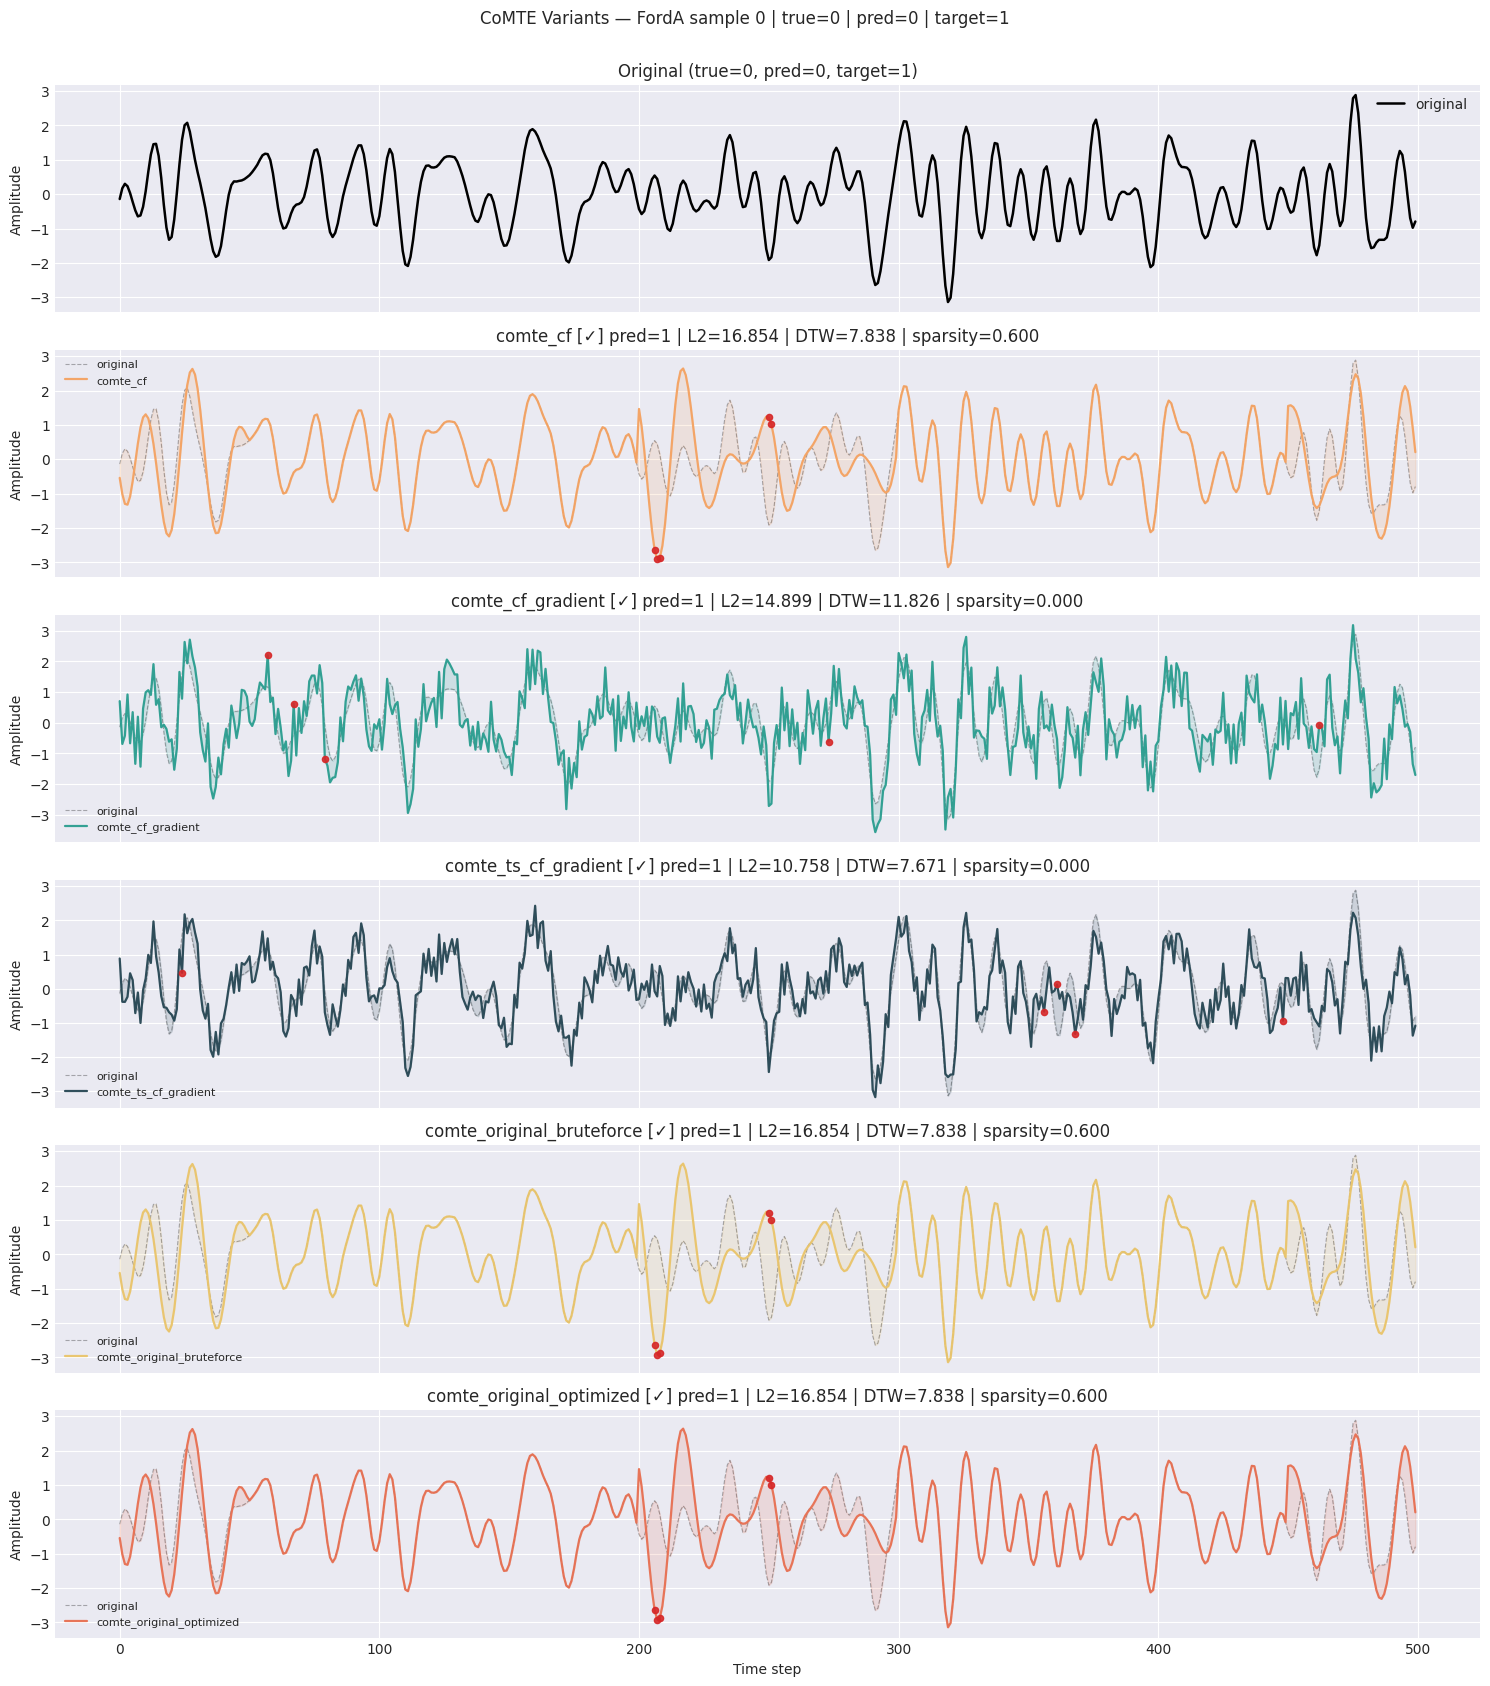

In [12]:
# Waveform comparison: original vs each CoMTE variant
rep = all_cfs[rep_idx]
x = to_channel_first(rep["sample"])[0]
x_axis = np.arange(len(x))

sample_results = results_df[results_df["sample_idx"] == rep_idx]
info_lookup = {
    row["method"]: {
        "success": bool(row["success"]),
        "pred_cf": int(row["pred_cf"]) if not pd.isna(row["pred_cf"]) else None,
        "l2": float(row["l2_norm"]) if not pd.isna(row["l2_norm"]) else np.nan,
        "dtw": float(row["dtw_proximity"]) if not pd.isna(row["dtw_proximity"]) else np.nan,
        "sparsity": float(row["sparsity"]) if not pd.isna(row["sparsity"]) else np.nan,
    }
    for _, row in sample_results.iterrows()
}

orig_row = sample_results.iloc[0]
true_label = int(orig_row["true_label"])
pred_orig = int(orig_row["pred_orig"])
target_class = int(orig_row["target_class"])

n_rows = 1 + len(method_names)
fig, axes = plt.subplots(n_rows, 1, figsize=(15, 2.8 * n_rows), sharex=True)
fig.suptitle(
    f"CoMTE Variants — FordA sample {rep_idx} | true={true_label} | pred={pred_orig} | target={target_class}",
    fontsize=12, y=1.001,
)

axes[0].plot(x, color="black", linewidth=1.8, label="original")
axes[0].set_title(f"Original (true={true_label}, pred={pred_orig}, target={target_class})")
axes[0].set_ylabel("Amplitude")
axes[0].legend(loc="best")

for i, method_name in enumerate(method_names, start=1):
    ax = axes[i]
    cf = rep.get(method_name)
    info = info_lookup.get(method_name, {})
    worked = info.get("success", False)
    pred_cf = info.get("pred_cf")
    l2_val = info.get("l2", np.nan)
    dtw_val = info.get("dtw", np.nan)
    sp_val = info.get("sparsity", np.nan)

    ax.plot(x, color="black", linewidth=0.8, linestyle="--", alpha=0.3, label="original")

    if cf is None:
        ax.text(0.5, 0.5, f"{method_name}: no CF available", ha="center", va="center", transform=ax.transAxes)
    else:
        cf_line = to_channel_first(cf)[0]
        color = METHOD_COLORS_ALL.get(method_name, "#888888")
        ax.plot(cf_line, linewidth=1.6, alpha=0.95, color=color, label=method_name)
        ax.fill_between(x_axis, x, cf_line, color=color, alpha=0.15)
        diff_abs = np.abs(cf_line - x)
        top_idx = np.argsort(diff_abs)[-5:] if diff_abs.size >= 5 else np.arange(diff_abs.size)
        ax.scatter(x_axis[top_idx], cf_line[top_idx], s=20, color="#d62728", alpha=0.9, zorder=4)

    status = "✓" if worked else "✗"
    ax.set_title(
        f"{method_name} [{status}] pred={pred_cf} | L2={l2_val:.3f} | DTW={dtw_val:.3f} | sparsity={sp_val:.3f}"
    )
    ax.set_ylabel("Amplitude")
    ax.legend(loc="best", fontsize=8)

axes[-1].set_xlabel("Time step")
plt.tight_layout(rect=[0, 0, 1, 0.998])
plt.show()

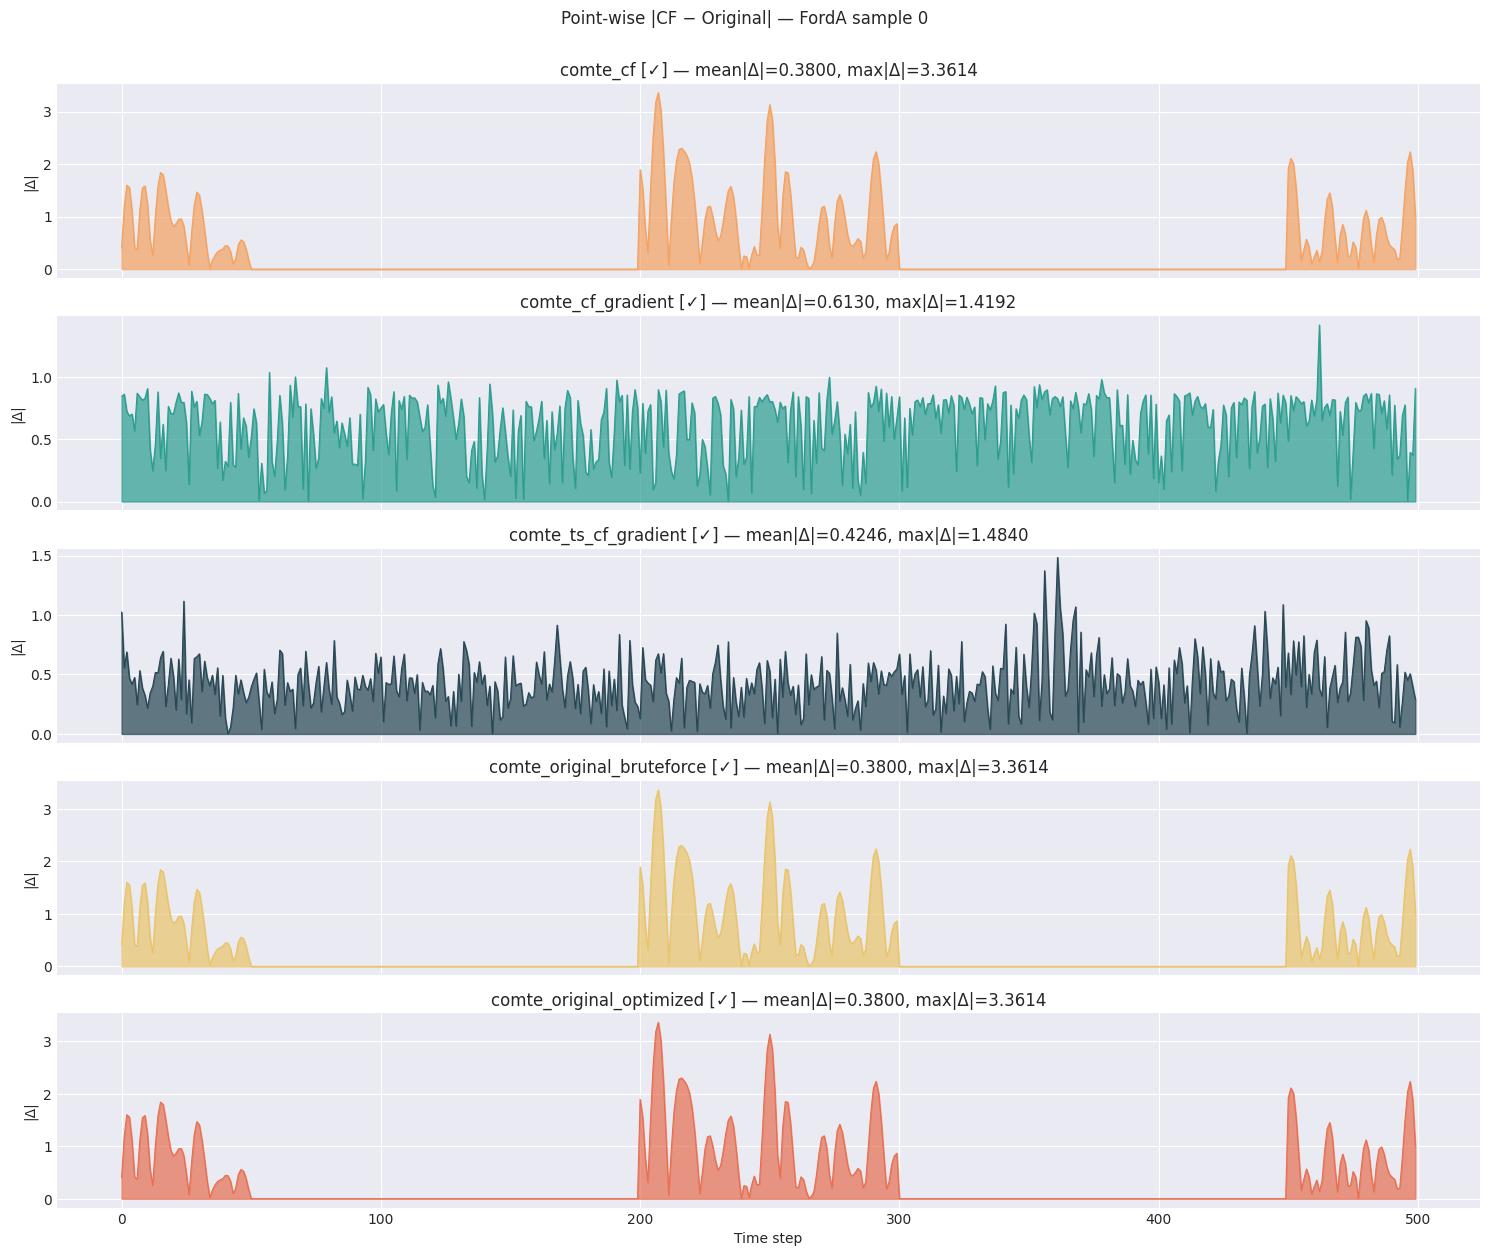

In [13]:
# Difference magnitude |CF - original| for each method on the representative sample
fig, axes = plt.subplots(len(method_names), 1, figsize=(15, 2.5 * len(method_names)), sharex=True)
fig.suptitle(
    f"Point-wise |CF − Original| — FordA sample {rep_idx}",
    fontsize=12, y=1.001,
)

for i, method_name in enumerate(method_names):
    ax = axes[i] if len(method_names) > 1 else axes
    cf = rep.get(method_name)
    color = METHOD_COLORS_ALL.get(method_name, "#888888")
    if cf is None:
        ax.text(0.5, 0.5, f"{method_name}: no CF", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(method_name)
        continue
    diff = np.abs(to_channel_first(cf)[0] - x)
    info = info_lookup.get(method_name, {})
    worked = info.get("success", False)
    status = "✓" if worked else "✗"
    ax.fill_between(x_axis, 0, diff, color=color, alpha=0.7)
    ax.plot(diff, color=color, linewidth=0.8)
    ax.set_title(f"{method_name} [{status}] — mean|Δ|={diff.mean():.4f}, max|Δ|={diff.max():.4f}")
    ax.set_ylabel("|Δ|")

axes[-1].set_xlabel("Time step") if len(method_names) > 1 else axes.set_xlabel("Time step")
plt.tight_layout(rect=[0, 0, 1, 0.998])
plt.show()

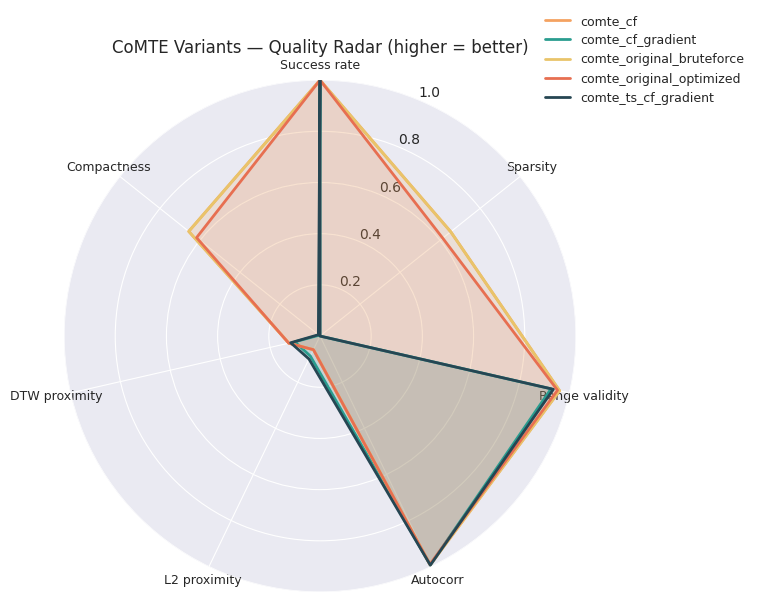

In [14]:
# Radar / spider chart summarizing key metrics (all inverted so higher=better)
radar_metrics = [
    "success_rate_norm",
    "sparsity_mean",
    "range_validity_mean",
    "autocorr_mean",
    "l2_score",
    "dtw_score",
    "keane_compactness_mean",
]
radar_labels = [
    "Success rate",
    "Sparsity",
    "Range validity",
    "Autocorr",
    "L2 proximity",
    "DTW proximity",
    "Compactness",
]

plot_df2 = plot_df.copy()
plot_df2["success_rate_norm"] = plot_df2["success_rate"] / 100.0
plot_df2["l2_score"] = 1.0 / (1.0 + plot_df2["l2_norm_mean"].fillna(np.inf))
plot_df2["dtw_score"] = 1.0 / (1.0 + plot_df2["dtw_proximity_mean"].fillna(np.inf))

N = len(radar_metrics)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, size=9)
ax.set_ylim(0, 1)

for row_i, row in plot_df2.iterrows():
    vals = [float(row.get(m, 0) or 0) for m in radar_metrics]
    vals += vals[:1]
    color = METHOD_COLORS_ALL.get(row["method"], "#888888")
    ax.plot(angles, vals, linewidth=2, linestyle="solid", label=row["method"], color=color)
    ax.fill(angles, vals, alpha=0.1, color=color)

ax.set_title("CoMTE Variants — Quality Radar (higher = better)", pad=20, fontsize=12)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=9)
plt.tight_layout()
plt.show()

In [15]:
# Show any errors that occurred during evaluation
errors = results_df[results_df["error"].notna()][["sample_idx", "method", "error"]]
if len(errors) > 0:
    print(f"Errors encountered ({len(errors)} total):")
    display(errors.head(20))
else:
    print("No errors encountered.")

No errors encountered.


## Takeaways

- **`comte_original_bruteforce` / `comte_original_optimized` / `comte_cf`** all implement the actual published algorithm: they only ever write back values that exist somewhere in a real, correctly-classified training example (via segment swaps), so their counterfactuals are, by construction, locally realistic mixtures of the original and a real distractor. Their proximity/sparsity numbers are governed by how many of the 10 segments needed to change, not by a tunable regularization weight.
- **`comte_cf` vs. `comte_original_bruteforce`**: both run the identical mechanism (distractor retrieval restricted to true-positive target-class examples, then greedy single-unit swaps, stop on first flip) — `comte_cf` is a from-scratch reimplementation against this repo's plain-PyTorch model interface rather than the official repo's sklearn-`Pipeline`/pandas-`MultiIndex` adapter, with no `mlrose`/`scikit-optimize`/`tables` dependency. Close agreement between the two here (success rate, sparsity, compactness) is evidence `comte_cf` is a faithful port, not just a same-flavored approximation.
- **`comte_cf_gradient` / `comte_ts_cf_gradient`** (this repo's legacy methods, `comte.py`) optimize the whole continuous waveform against a differentiable objective, so they can reach far higher validity/success rates and arbitrarily small L2 distance (by tuning `lambda_reg`), but the resulting waveform is not guaranteed to look like anything in the data distribution — nothing constrains it to match real sensor behavior the way a distractor-based swap does.
- Because these are genuinely different mechanisms, treat the `comte_cf_gradient` / `comte_ts_cf_gradient` numbers here as a **behavioral comparison** against the real algorithm, not a validation that they reproduce the paper's method — they don't, and the "Why `comte_cf_gradient` / `comte_ts_cf_gradient` are not the paper's algorithm" note at the top explains why.